# Transferring of immune cell states from the Gut Cell Atlas (Elementaite, 2021) to Remapped Data Using the `scVI - scANVI` Pipeline

**Developed by:** Anna Maguza\
**Affiliation:** Faculty of Medicine, Würzburg University\
**Creation date:** 3rd February 2025\
**Last modified date:** 3rd February 2025

#### **Objective**

This notebook outlines the process for transferring immune cell states annotations from the Gut Cell Atlas (Elementaite, 2021) to a series of remapped datasets using the `scVI - scANVI` pipeline. Our goal is to ensure consistent annotation of cell types across studies and to identify cells requiring manual validation.\
We analyze the confidence scores produced by `scANVI` to identify cells with low classification certainty. These cells are flagged for potential manual review and validation to ensure the accuracy of the annotations.\
Finally, we evaluate the performance of the `scVI` and `scANVI` models using `scIB` metrics. This step helps quantify the quality of the integration, classification, and batch correction.

## Import packages

In [1]:
import scvi
import torch
import anndata
import warnings
import numpy as np
import scanpy as sc
import anndata
import pandas as pd
import plotnine as p
import matplotlib.pyplot as plt
import seaborn as sns
from scib_metrics.benchmark import Benchmarker

import json
from datetime import datetime

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup working environment

In [2]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi = 180, color_map = 'magma_r', dpi_save = 300, vector_friendly = True, format = 'svg')

In [3]:
warnings.simplefilter(action = 'ignore')
scvi.settings.seed = 1712
%config InlineBackend.print_figure_kwargs = {'facecolor' : "w"}
%config InlineBackend.figure_format = 'retina'
torch.set_float32_matmul_precision('medium')

Seed set to 1712


In [4]:
arches_params = dict(
    use_layer_norm = "both",
    use_batch_norm = "none",
    encode_covariates = True,
    dropout_rate = 0.2,
    n_layers = 3,
)

In [5]:
def X_is_raw(adata):
    return np.array_equal(adata.X.sum(axis=0).astype(int), adata.X.sum(axis=0))

In [6]:
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')

## Upload data

In [7]:
adata = sc.read_h5ad('data/gut_data/gut_hs_all_datasets_scVI_scANVI_celltypes_AM_10012025_100142_raw.h5ad')
adata

AnnData object with n_obs × n_vars = 402343 × 43704
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protoc

In [8]:
adata.obs['celltype'] = adata.obs['C_scANVI']

In [9]:
adata = adata[adata.obs['celltype'].isin(['T cells', 'Myeloid', 'B cells', 'Plasma cells'])].copy()

In [10]:
del adata.obs['_scvi_batch'], adata.obs['_scvi_labels'], adata.obs['C_scANVI'], adata.obs['confidence_score']
del adata.obsm
del adata.uns

In [11]:
adata

AnnData object with n_obs × n_vars = 61109 × 43704
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protoco

In [12]:
X_is_raw(adata)

True

## Prepare observations

In [13]:
adata.obs['Protocol REF'] = adata.obs['Protocol REF'].cat.add_categories('Unknown')
adata.obs['Protocol REF'] = adata.obs['Protocol REF'].replace(['  '], 'Unknown')

In [14]:
adata.obs['Protocol REF'].value_counts()

Protocol REF
P-MTAB-101781    30730
Unknown          14373
P-MTAB-100978    10911
P-MTAB-100897     2352
P-MTAB-102913     1727
P-MTAB-95162      1016
Name: count, dtype: int64

In [15]:
adata.obs['Performer'].value_counts()

Performer
University of Michigan DNA Sequencing core                                                           30730
Wellcome Sanger Institute                                                                            15389
Wellcome Sanger Institute Cellular Generation and Phenotyping teaml, Kylie James, Rasa Elmentaite    10911
Rasa Elmentaite, Kylie James                                                                          2352
University of Michigan Advanced Genomics Core                                                         1727
Name: count, dtype: int64

In [16]:
adata.obs['library_construction'] = adata.obs['library_construction'].astype(str)
adata.obs['LIBRARY_LAYOUT'] = adata.obs['LIBRARY_LAYOUT'].astype(str)
adata.obs['library_construnction_and_layout'] = adata.obs['library_construction'] + '_' + adata.obs['LIBRARY_LAYOUT']
adata.obs['library_construnction_and_layout'].value_counts()

library_construnction_and_layout
10xV2_PAIRED    28652
10xV2_SINGLE    26359
10xV3_SINGLE     4371
10xV3_PAIRED     1727
Name: count, dtype: int64

In [17]:
adata.obs['donor_id'] = adata.obs['donor_id'].cat.add_categories('cell_culture')
adata.obs['donor_id'] = adata.obs['donor_id'].replace(['nan'], 'cell_culture')

+ Delete samples with less than 10 cells

In [18]:
cell_counts = adata.obs['sample_id'].value_counts()
samples_to_remove = cell_counts[cell_counts < 10].index
adata = adata[~adata.obs['sample_id'].isin(samples_to_remove)].copy()

+ Delete not mesenchymal cell states 

In [19]:
adata.obs['Integrated_05'].value_counts()

Integrated_05
Unknown                          39072
IgA plasma cell                   4689
Naive B                           2046
Activated CD8 T                   1829
Memory B                          1471
Cycling B cell                     977
gdT                                826
SELL+ CD4 T                        739
Tfh                                653
Macrophages                        651
Activated CD4 T                    637
GC B cell                          633
LYVE1+ Macrophage                  554
DZ GC cell                         520
cDC2                               407
CD8 Tmem                           394
TRGV4 gdT                          381
NK cell                            377
Cycling plasma cell                374
Treg                               329
SELL+ CD8 T                        300
Th17                               276
LZ GC cell                         274
IgG plasma cell                    240
TRGV2 gdT                          209
Monocytes  

In [20]:
adata = adata[adata.obs['Integrated_05'] != 'Mesoderm 2 (ZEB2+)']

+ Relabel into broader annotation

In [21]:
cell_state_mapping = {
    'Unknown': 'Unknown',
    # Plasma cells
    'IgA plasma cell': 'IgA plasma cell',
    'IgG plasma cell': 'IgG plasma cell',
    'IgM plasma cell': 'IgM plasma cell',
    'Cycling plasma cell': 'Cycling plasma cell',
    
    # B cells
    'Naive B': 'Naive B cells',
    'Memory B': 'Memory B cells',
    'FCRL4+ Memory B': 'Memory B cells',
    'Cycling B cell': 'Cycling B cell',
    'GC B cell': 'Germinal Center B cells',
    'DZ GC cell': 'Germinal Center B cells',
    'LZ GC cell': 'Germinal Center B cells',
    'Pro-B': 'Early B cells',
    'Pre-B': 'Early B cells',
    'Immature B': 'Early B cells',
    'STAT1+ Naive B': 'Naive B cells',
    
    # CD8 T cells
    'Activated CD8 T': 'Activated CD8 T cells',
    'SELL+ CD8 T': 'Naive CD8 T cells',
    'CD8 Tmem': 'Memory CD8 T cells',
    'CX3CR1+ CD8 Tmem': 'Memory CD8 T cells',
    
    # CD4 T cells
    'Activated CD4 T': 'Activated CD4 T cells',
    'SELL+ CD4 T': 'Naive CD4 T cells',
    'Tfh': 'T helper',
    'Treg': 'Treg',
    'Th17': 'T helper',
    'Th1': 'T helper',
    
    # Other T cells
    'Activated T': 'Activated T',
    'MAIT cell': 'MAIT cell',
    'NK T cell': 'NK T cell',
    
    # gamma delta T cells
    'gdT': 'gamma delta T cells',
    'TRGV4 gdT': 'gamma delta T cells',
    'TRGV2 gdT': 'gamma delta T cells',
    'TRGV5/7 gdT': 'gamma delta T cells',
    
    # NK and ILCs
    'NK cell': 'NK cells',
    'ILC2': 'ILCs',
    'ILC3': 'ILCs',
    'LTi-like NCR- ILC3': 'ILCs',
    'LTi-like NCR+ ILC3': 'ILCs',
    'ILCP': 'ILCs',
    
    # Myeloid cells
    'Macrophages': 'Macrophages',
    'LYVE1+ Macrophage': 'Macrophages',
    'MMP9+ Inflammatory macrophage': 'Macrophages',
    'Monocytes': 'Monocytes',
    'MPO+ mono-neutrophil': 'Monocytes',
    'cDC1': 'Dendritic cells',
    'cDC2': 'Dendritic cells',
    'pDC': 'Dendritic cells',
    'Lymphoid DC': 'Dendritic cells',
    'FDC': 'Dendritic cells',
    'Mast cell': 'Mast cells',
    'CLC+ Mast cell': 'Mast cells',
    'CLP': 'Progenitors',
    'Megakaryocyte': 'Megakaryocyte'
}


In [22]:
adata.obs['cell_state'] = adata.obs['Integrated_05'].map(cell_state_mapping)

+ Delete doublets

In [23]:
adata = adata[adata.obs['predicted_doublets'] != 'True']

+ Fix issue with Boolean None

In [24]:
adata.obs['cell_type'] = adata.obs['cell_type'].replace(['  '], 'unsorted')
adata.obs['cell_type'] = adata.obs['cell_type'].replace(['epithelial cell'], 'intestinal epithelial cell')
adata.obs['cell_type'] = adata.obs['cell_type'].cat.remove_unused_categories()
adata.obs['cell_type'] = adata.obs['cell_type'].fillna('unsorted')

In [25]:
adata.obs['cluster_passed_qc'] = adata.obs['cluster_passed_qc'].astype(str)
adata.obs['cluster_passed_qc'] = adata.obs['cluster_passed_qc'].fillna('N/A')
adata.obs['consensus_fraction'] = adata.obs['consensus_fraction'].astype(str)
adata.obs['consensus_fraction'] = adata.obs['consensus_fraction'].fillna('N/A')
adata.obs['consensus_passed_qc'] = adata.obs['consensus_passed_qc'].astype(str)
adata.obs['consensus_passed_qc'] = adata.obs['consensus_passed_qc'].fillna('N/A')
adata.obs['qc_cluster'] = adata.obs['qc_cluster'].astype(str)
adata.obs['qc_cluster'] = adata.obs['qc_cluster'].fillna('N/A')

In [26]:
adata.obs['gestational_age'] = adata.obs['gestational_age'].cat.add_categories('N/A - not fetal')
adata.obs['gestational_age'] = adata.obs['gestational_age'].replace(['  '], 'N/A - not fetal')
adata.obs['gestational_age'] = adata.obs['gestational_age'].fillna('N/A - not fetal')
adata.obs['gestational_age'].value_counts()

gestational_age
N/A - not fetal    58883
10.4                 303
11.9                 300
12.2                  98
11.2                  92
8.1                   70
8.9                   64
9.9                   29
7.4                   25
Name: count, dtype: int64

In [27]:
adata.obs['passage'] = adata.obs['passage'].cat.add_categories('N/A')
adata.obs['passage'] = adata.obs['passage'].replace(['  '], 'N/A')
adata.obs['passage'] = adata.obs['passage'].fillna('N/A')
adata.obs['passage'].value_counts()

passage
N/A    59839
17        25
Name: count, dtype: int64

In [28]:
adata.obs['batch'] = adata.obs['batch'].cat.add_categories('unknown')
adata.obs['batch'] = adata.obs['batch'].fillna('unknown')

In [29]:
adata.obs['sampling_site'] = adata.obs['sampling_site'].cat.add_categories('unknown')
adata.obs['sampling_site'] = adata.obs['sampling_site'].replace(['  '], 'unknown')
adata.obs['sampling_site'] = adata.obs['sampling_site'].fillna('unknown')

In [30]:
nan_summary = adata.obs.isna().sum()

print(nan_summary[nan_summary > 0])

time    58137
dtype: int64


## Visualize uncorrected dataset

In [31]:
adata_log = adata.copy()
sc.pp.normalize_total(adata_log, target_sum=1e6, exclude_highly_expressed=True)
sc.pp.log1p(adata_log)

normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['C1QB', 'JUN', 'S100A9', 'S100A12', 'S100A8', 'S100A6', 'RPS27', 'TMSB10', 'GNLY', 'IGKV4-1', 'IGKV2D-29', 'IGKV2D-24', 'IGKV3D-20', 'IGKV1D-16', 'IGKV1D-13', 'IGKV3D-11', 'SST', 'ENSG00000286848', 'JCHAIN', 'CXCL8', 'CXCL10', 'SPP1', 'CCDC152', 'GZMA', 'ATG10', 'CD74', 'SOX4', 'ENSG00000271581', 'ACTB', 'ENSG00000272256', 'RPL30-AS1', 'TXN', 'LCN2', 'VIM-AS1', 'PSAP', 'PRADX', 'BEST1', 'TALAM1', 'ENSG00000272173', 'CD69', 'RPS26', 'LYZ', 'ENSG00000257764', 'BTG1-DT', 'UQCC6', 'TPT1', 'ENSG00000273149', 'RNASE1', 'HSP90AA1', 'IGHA2', 'IGHV2-70', 'SNX22', 'ENSG00000290038', 'ENSG00000290010', 'TPSAB1', 'MT2A', 'RPL13', 'ENO3', 'ENSG00000265401', 'H3-3B', 'JSRP1', 'ENSG00000280194', 'CLC', 'FTL', 'PRAMENP', 'IGLV4-69', 'IGLV8-61', 'IGLV4-60', 'IGLV6-57', 'IGLV1-51', 'IGLV1-47', 'IGLV7-46', 'IGLV3-25', 'IGLV2-23', 'IGLV3-21', 'IGLV3-19', 'IGLV2-18', 'IGLV2-14', 'I

In [32]:
sc.pp.pca(adata_log)

computing PCA
    with n_comps=50
    finished (0:01:05)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [33]:
sc.pp.neighbors(adata_log, n_neighbors=15, n_pcs=50)
sc.tl.umap(adata_log)

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:11)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:39)


In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.pca(adata_log,color=['celltype', "Study_name", "ArrayExpress_ID", 'age_group', 'organism_part', 'developmental_stage', 'library_preparation_protocol', 'library_construnction_and_layout', 'Protocol REF', 'Performer'], ncols=4, frameon=False, show=False, size = 5)
    plt.savefig(f"figures/immune_pca_uncorrected_categorical_values1_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.pca(adata_log,color=['immunophenotype', 'sex', 'Cell_cycle_phase', 'full_age', 'growth_condition', 'sampling_site', 'Material Type', 'donor_id', 'library_construnction_and_layout', 'Protocol REF', 'Performer'], ncols=4, frameon=False, show=False, size = 5)
    plt.savefig(f"figures/immune_pca_uncorrected_categorical_values2_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(7, 7))
    sc.pl.pca(adata_log,color=['n_genes', 'n_counts', 'total_counts', 'n_genes_by_counts', 'predicted_doublets', 'percent_mito', 'percent_ribo', 'percent_hb'], color_map = 'magma_r', ncols=4, frameon=False, show=False, size = 5)
    plt.savefig(f"figures/immune_pca_uncorrected_continues_values_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.umap(adata_log,color=['celltype',"Study_name", "ArrayExpress_ID", 'age_group', 'organism_part', 'developmental_stage', 'library_preparation_protocol', 'library_construnction_and_layout', 'Protocol REF', 'Performer'], ncols=4, frameon=False, show=False, size = 5)
    plt.savefig(f"figures/immune_umap_uncorrected_categorical_values1_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.umap(adata_log,color=['immunophenotype', 'sex', 'Cell_cycle_phase', 'full_age', 'growth_condition', 'sampling_site', 'Material Type', 'donor_id', 'library_construnction_and_layout', 'Protocol REF', 'Performer'], ncols=4, frameon=False, show=False, size = 5)
    plt.savefig(f"figures/immune_umap_uncorrected_categorical_values2_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(7, 7))
    sc.pl.umap(adata_log,color=['n_genes', 'n_counts', 'total_counts', 'n_genes_by_counts', 'predicted_doublets', 'percent_mito', 'percent_ribo', 'percent_hb'], color_map = 'magma_r', ncols=4, frameon=False, show=False, size = 5)
    plt.savefig(f"figures/immune_umap_uncorrected_continues_values_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [40]:
adata.obsm['X_pca'] = adata_log.obsm['X_pca'].copy()
adata.obsm['umap_uncorrected'] = adata_log.obsm['X_umap'].copy()

In [41]:
del adata_log

In [42]:
adata_raw = adata.copy()

## Extract highly variable genes

We extract the highly variable genes from the old reference dataset.

In [43]:
adata_ref = sc.read_h5ad('/Users/annamaguza/Desktop/data/gut_data/Integrated_4_datasets_05042024.h5ad')

In [44]:
adata_ref.layers["counts"] = adata_ref.X.copy()

In [45]:
sc.pp.highly_variable_genes(
    adata_ref,
    flavor = "seurat_v3",
    n_top_genes = 7000,
    layer = "counts",
    batch_key = "Library_Preparation_Protocol",
    subset = True,
    span = 1
)

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


In [46]:
genes_to_keep = adata_ref.var_names.intersection(adata.var_names)
adata = adata[:, genes_to_keep].copy()

In [47]:
del adata_ref

## Run scVI

In [48]:
adata.layers['counts'] = adata.X.copy()

In [50]:
adata.obs.rename(columns={'cell_state': 'cell_states'}, inplace=True)

In [51]:
scvi.model.SCVI.setup_anndata(adata, 
                              categorical_covariate_keys=['sample_id', 'library_construnction_and_layout', 'Performer', 'Protocol REF'],
                              labels_key = "cell_states", 
                              layer = 'counts')

In [52]:
scvi_model = scvi.model.SCVI(adata,
                            n_latent = 150, 
                            n_hidden = 256,
                            n_layers = 3, 
                            dropout_rate = 0.1,
                            dispersion = 'gene-cell', 
                            gene_likelihood = 'nb')

In [53]:
scvi_model.train(300, 
                early_stopping = True,
                early_stopping_patience = 10,
                check_val_every_n_epoch = 1, 
                enable_progress_bar = True)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Epoch 179/300:  60%|████████████████████████████████████████████████████████████████████████████████████████████████████▊                                                                    | 179/300 [56:22<38:06, 18.90s/it, v_num=1, train_loss_step=703, train_loss_epoch=734]
Monitored metric elbo_validation did not improve in the last 10 records. Best score: 757.294. Signaling Trainer to stop.


In [54]:
adata.obsm["X_scVI"] = scvi_model.get_latent_representation(adata)

#### Evaluate model performance using the [_Svensson_](https://www.nxn.se/valent/2023/8/10/training-scvi-posterior-predictive-distributions-over-epochs) method

In [55]:
history_df = (
    scvi_model.history['elbo_train'].astype(float)
    .join(scvi_model.history['elbo_validation'].astype(float))
    .reset_index()
    .melt(id_vars=['epoch'])
)

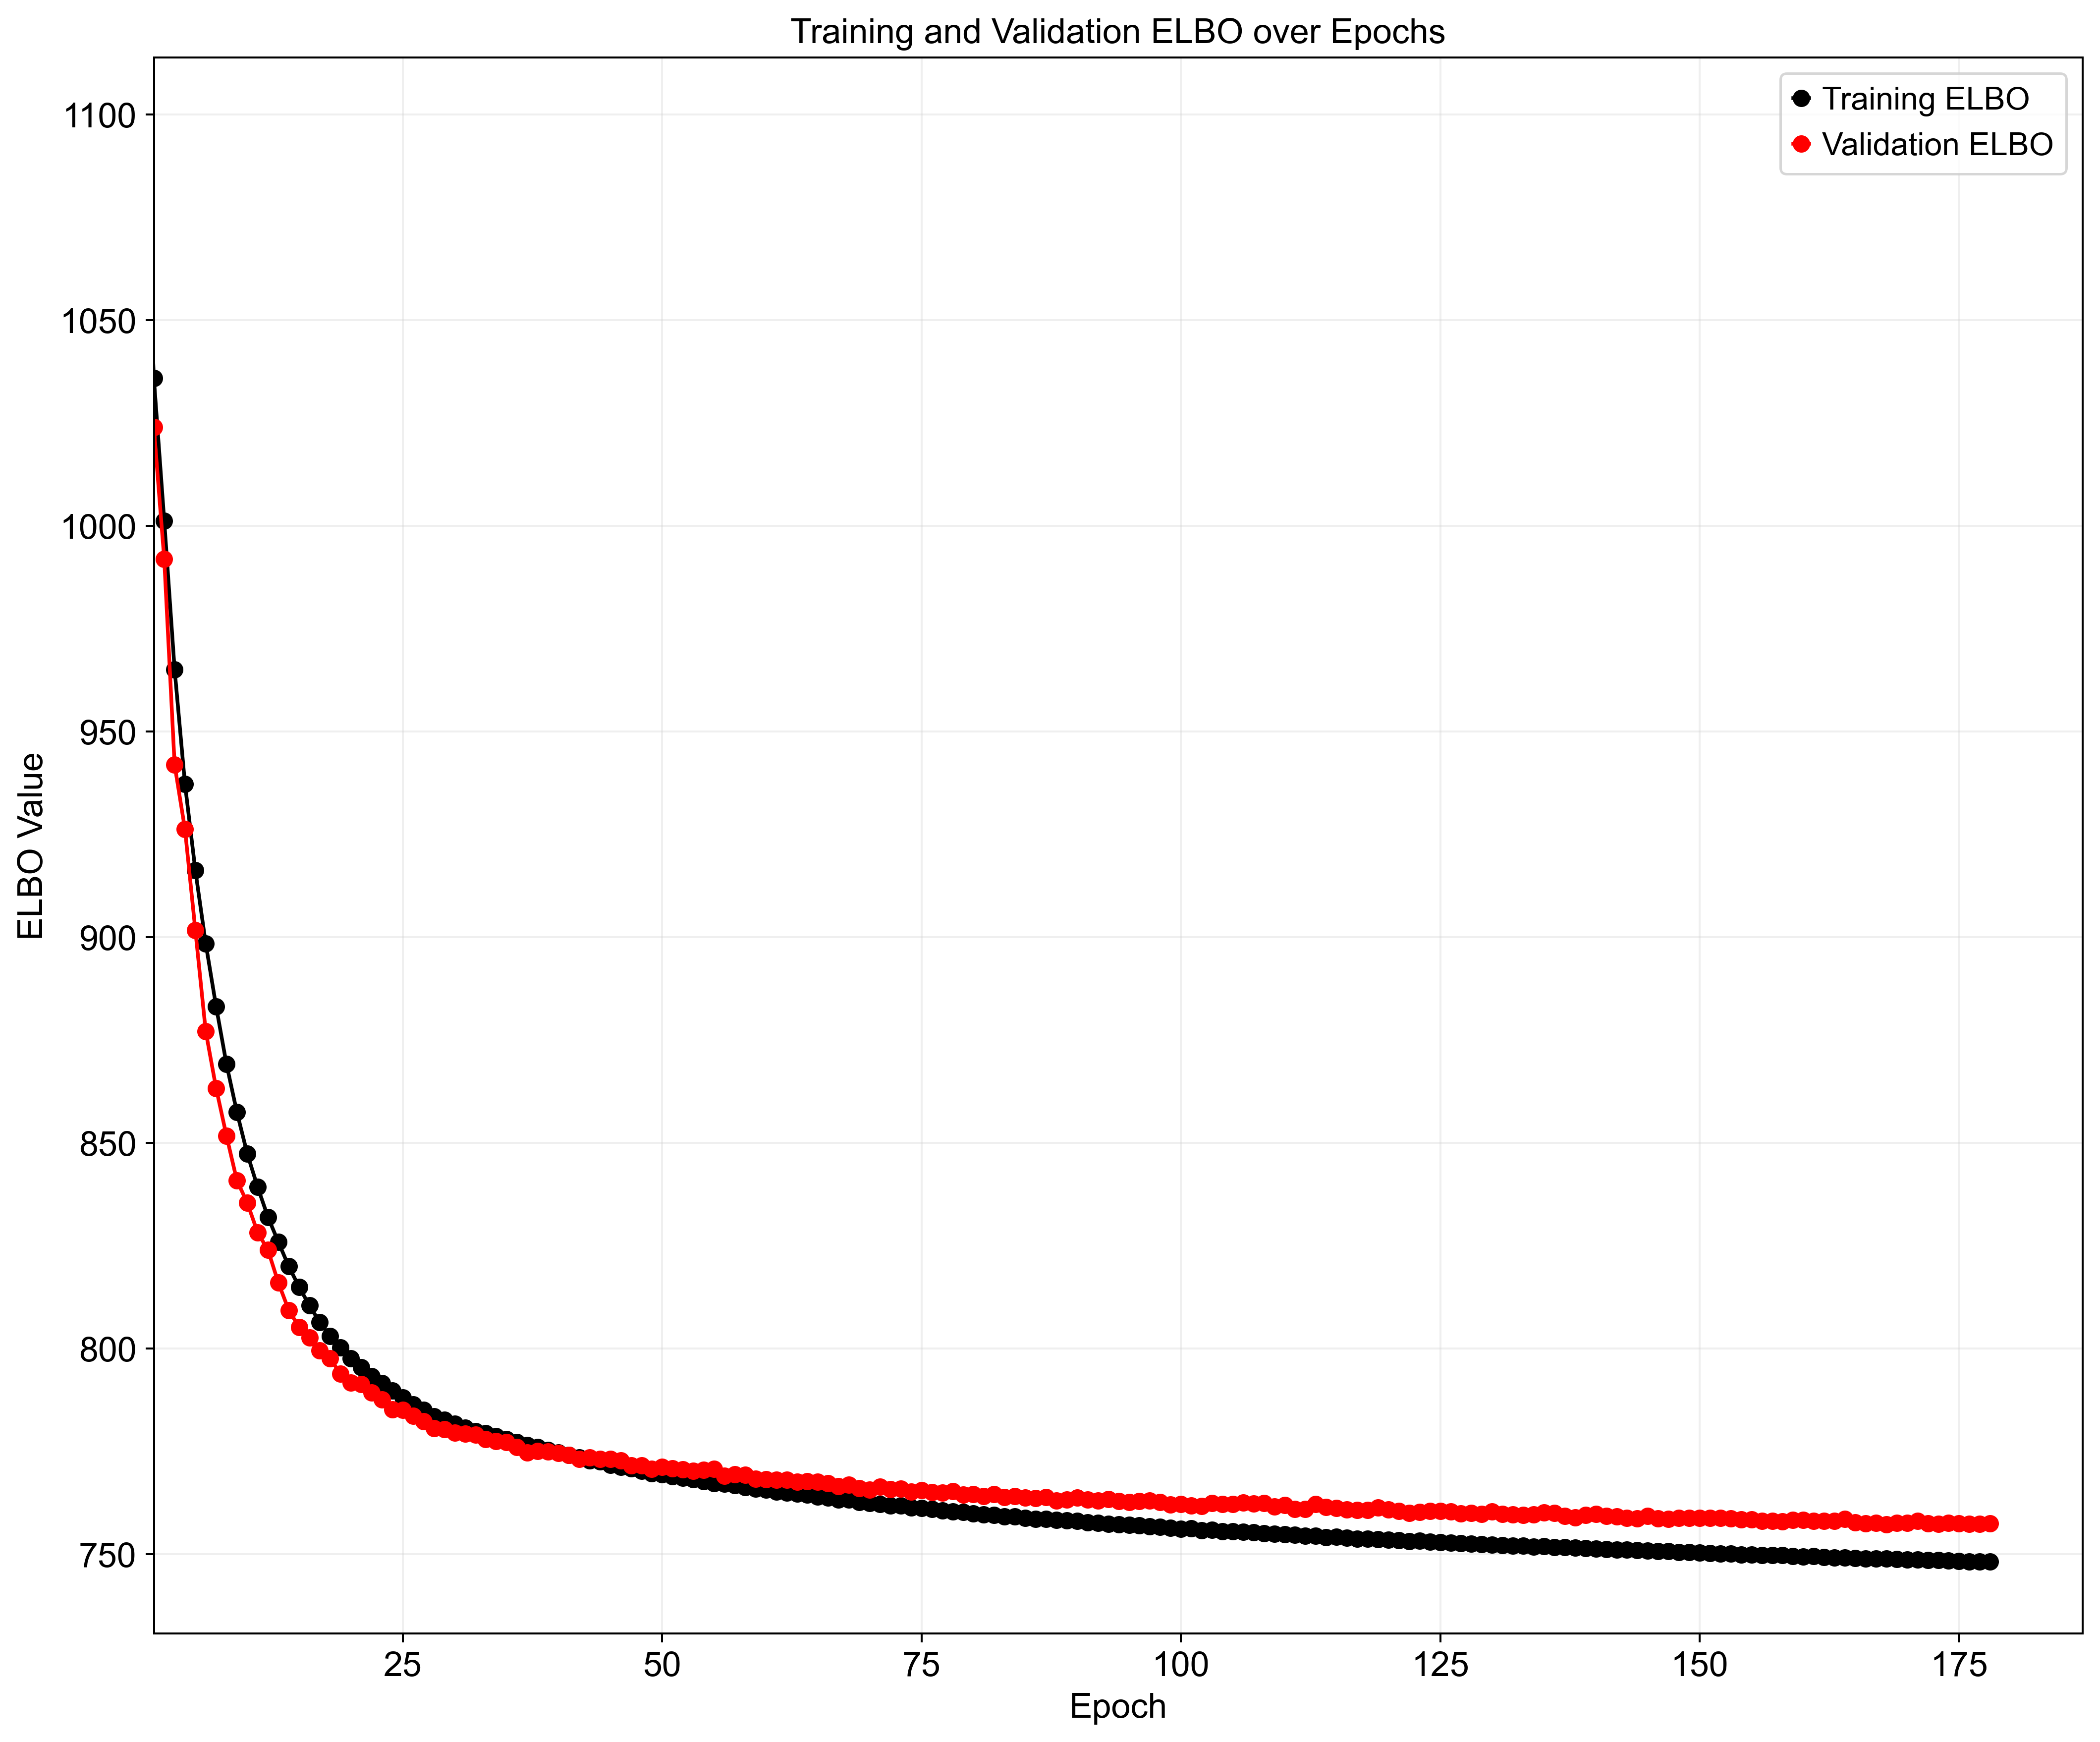

In [56]:
plt.figure(figsize=(12, 10))

plt.plot(history_df[history_df['variable'] == 'elbo_train']['epoch'], 
         history_df[history_df['variable'] == 'elbo_train']['value'], 
         color='black', marker='o', label='Training ELBO')

plt.plot(history_df[history_df['variable'] == 'elbo_validation']['epoch'],
         history_df[history_df['variable'] == 'elbo_validation']['value'], 
         color='red', marker='o', label='Validation ELBO')

plt.xlabel('Epoch')
plt.ylabel('ELBO Value')
plt.title('Training and Validation ELBO over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.xlim(left=1)

plt.tight_layout()
plt.show()

#### Label transfer with `scANVI` 

In [57]:
scanvi_model = scvi.model.SCANVI.from_scvi_model(scvi_model, 'Unknown')

In [58]:
scanvi_model.train(300, 
                     early_stopping = True,
                   check_val_every_n_epoch = 1, 
                   enable_progress_bar = True)

INFO     Training for 300 epochs.                                                                                  


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Epoch 300/300: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [4:34:23<00:00, 78.33s/it, v_num=1, train_loss_step=659, train_loss_epoch=736]

`Trainer.fit` stopped: `max_epochs=300` reached.


Epoch 300/300: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [4:34:23<00:00, 54.88s/it, v_num=1, train_loss_step=659, train_loss_epoch=736]


In [59]:
adata.obs["cellstates_scANVI"] = scanvi_model.predict(adata)

- Extract latent representation

In [60]:
adata.obsm["X_scANVI"] = scanvi_model.get_latent_representation(adata)

### Explore model performance using the [_Svensson_](https://www.nxn.se/valent/2023/8/10/training-scvi-posterior-predictive-distributions-over-epochs) method

In [61]:
history_df = (
    scanvi_model.history['elbo_train'].astype(float)
    .join(scanvi_model.history['elbo_validation'].astype(float))
    .reset_index()
    .melt(id_vars = ['epoch'])
)

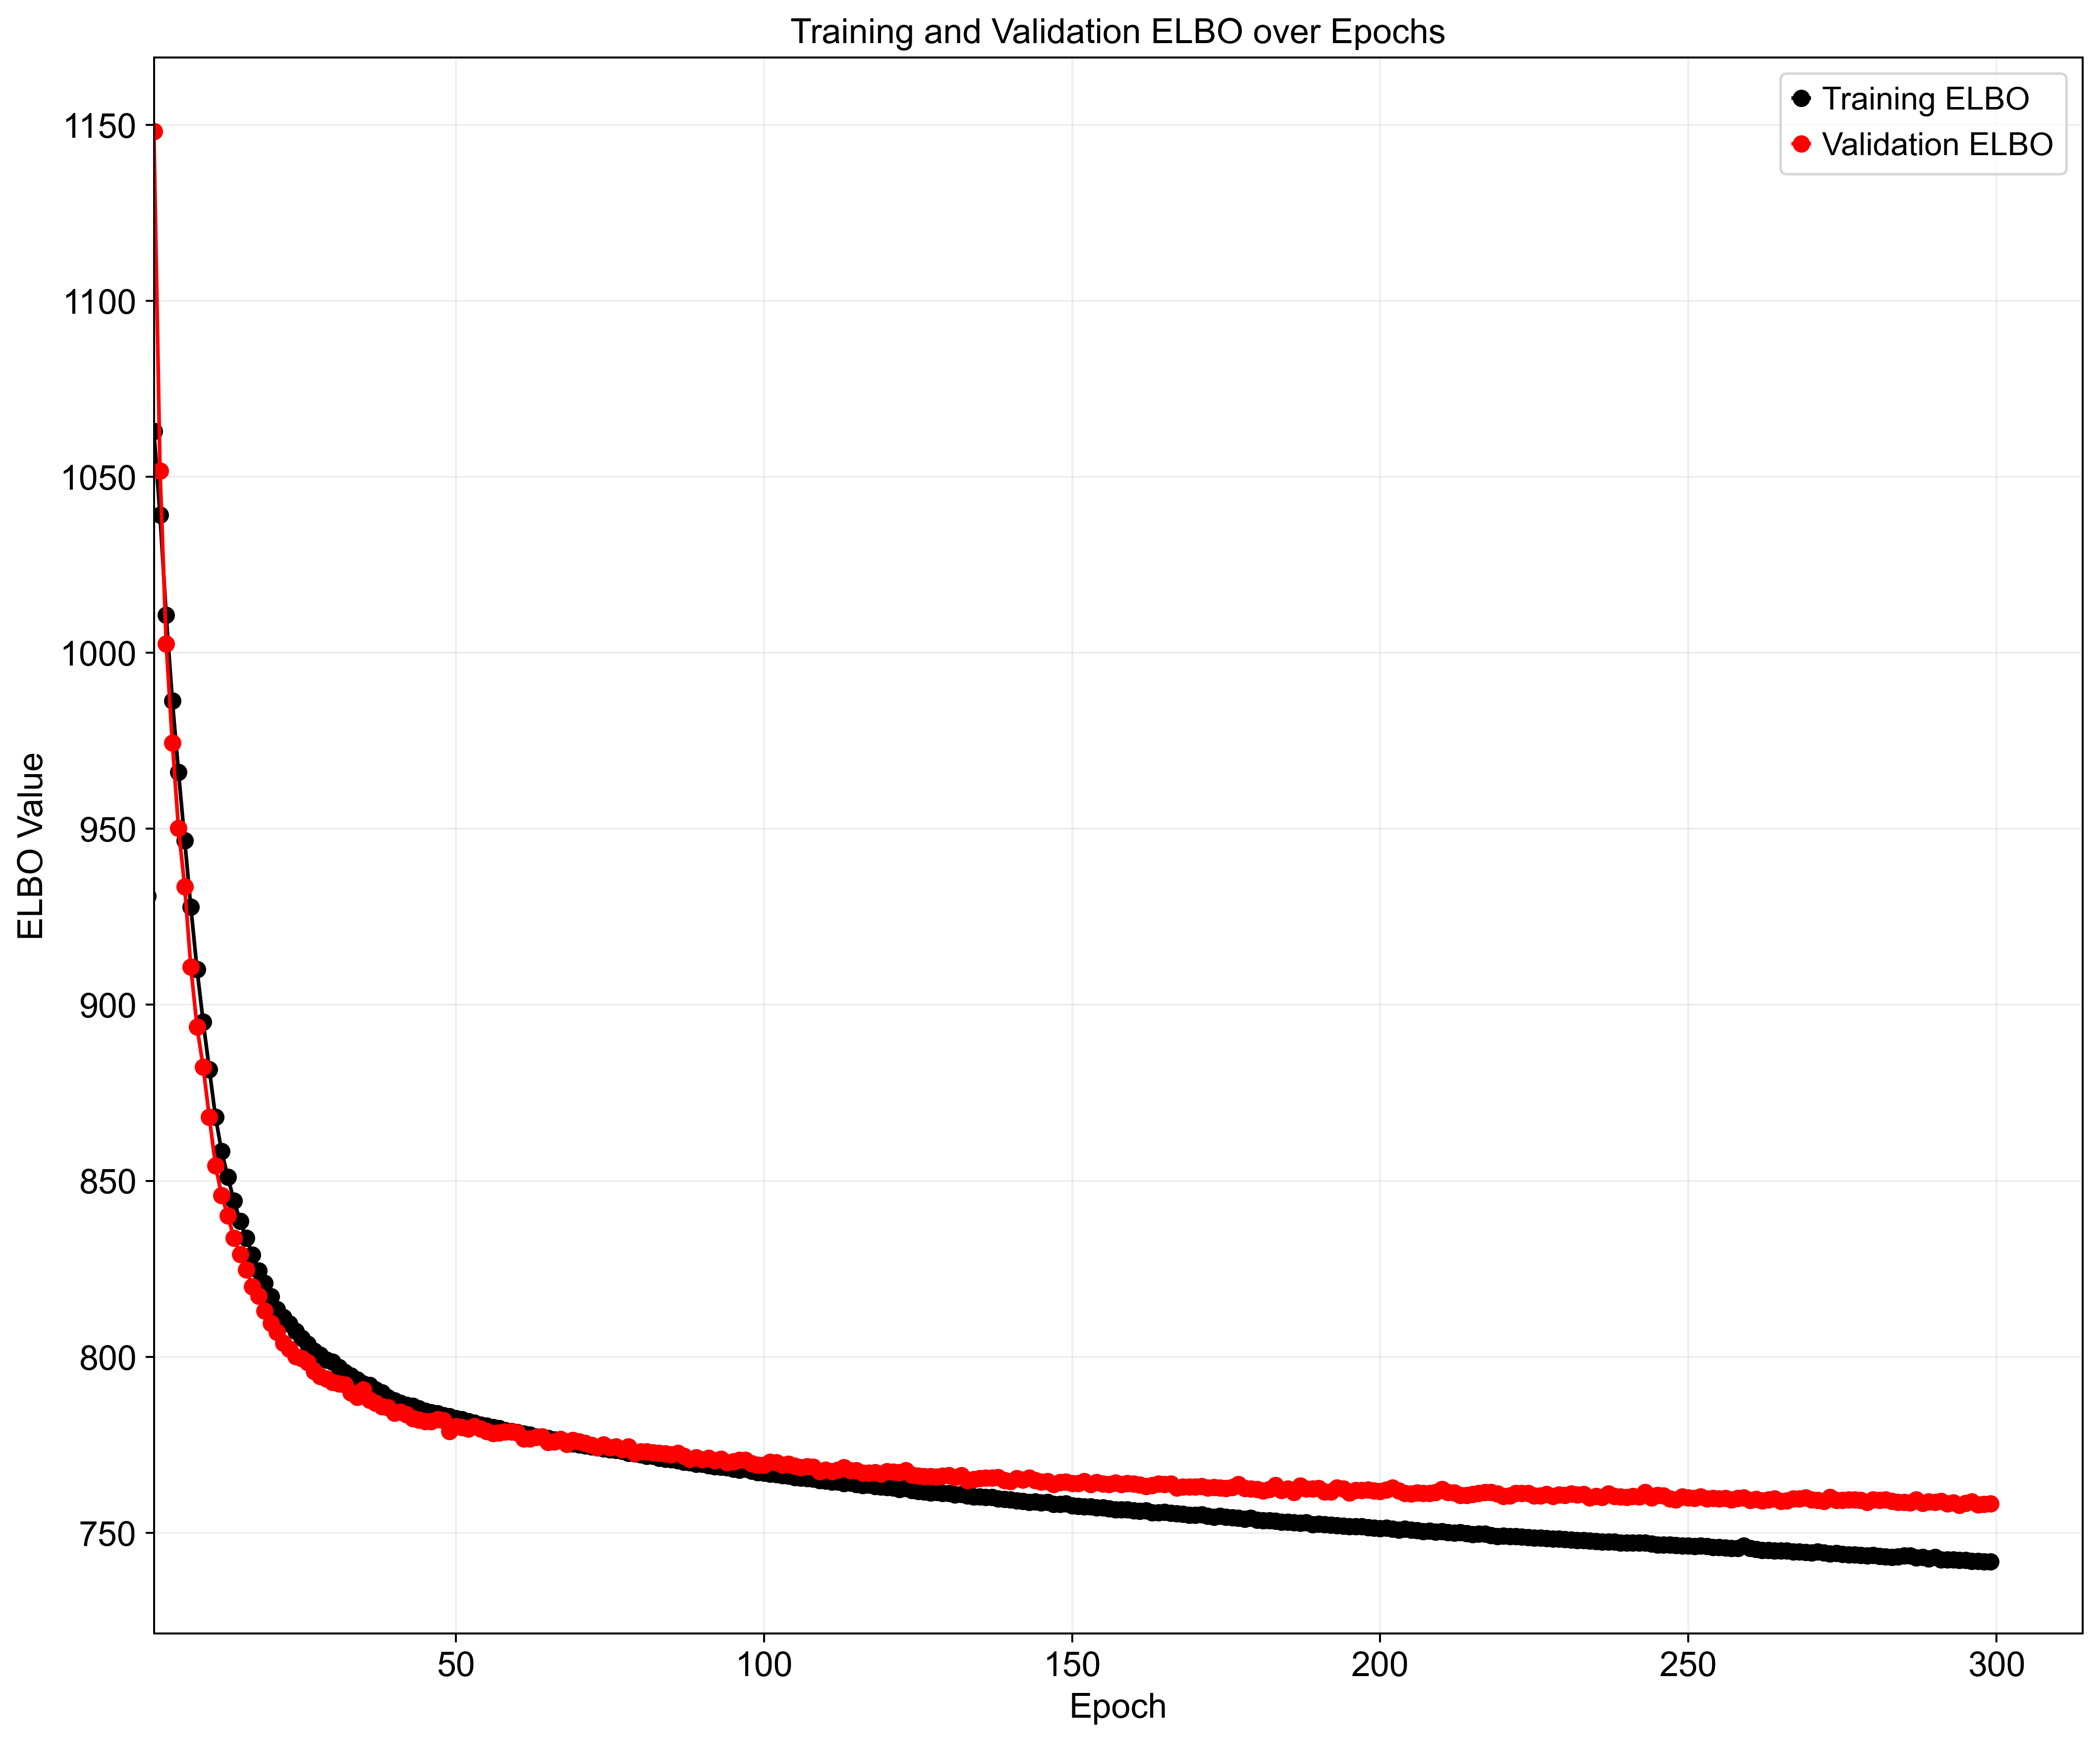

In [62]:
plt.figure(figsize=(12, 10))

plt.plot(history_df[history_df['variable'] == 'elbo_train']['epoch'], 
         history_df[history_df['variable'] == 'elbo_train']['value'], 
         color='black', marker='o', label='Training ELBO')

plt.plot(history_df[history_df['variable'] == 'elbo_validation']['epoch'],
         history_df[history_df['variable'] == 'elbo_validation']['value'], 
         color='red', marker='o', label='Validation ELBO')

plt.xlabel('Epoch')
plt.ylabel('ELBO Value')
plt.title('Training and Validation ELBO over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.xlim(left=1)

plt.tight_layout()
plt.show()

In [63]:
posterior_probs = scanvi_model.predict(adata, soft=True)

In [64]:
confidence_scores = posterior_probs.max(axis=1)

In [65]:
adata.obs['confidence_score'] = confidence_scores

+ Visualize dataset

In [66]:
sc.pp.neighbors(adata, use_rep = "X_scANVI", n_neighbors = 150, metric = 'minkowski')
sc.tl.umap(adata, min_dist = 0.6, spread = 8, random_state = 1712)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:01:13)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:44)


In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.umap(adata,color=["cellstates_scANVI", "confidence_score", 'cell_states', 'Integrated_05'], ncols=1, frameon=False, show=False, size = 6)
    plt.savefig(f"figures/immune_cellstates_transfer_categorical_values1_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.umap(adata,color=["Study_name", "ArrayExpress_ID", 'age_group', 'organism_part', 
                            'developmental_stage', 'library_preparation_protocol', 'immunophenotype', 'developmental_stage'], ncols=4, frameon=False, show=False, size = 6)
    plt.savefig(f"figures/immune_cellstates_transfer_categorical_values2_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=['sex', 'Cell_cycle_phase', 'sampling_site', 'full_age', 
                            'library_construnction_and_layout', 'Protocol REF', 'Performer', 'growth_condition', 
                            'Material Type', 'donor_id'], ncols=4, frameon=False, show=False, size = 10)
    plt.savefig(f"figures/immune_cellstates_transfer_categorical_values3_{timestamp}.png", bbox_inches="tight")
    #plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=['n_genes', 'n_counts', 'total_counts', 'n_genes_by_counts', 'predicted_doublets', 'percent_mito', 'percent_ribo', 'percent_hb'], color_map = 'magma_r', ncols=4, frameon=False, show=False, size = 10)
    plt.savefig(f"figures/immune_cellstates_transfer_continues_values_{timestamp}.png", bbox_inches="tight")
    #plt.show()

## Save prepared dataset

In [67]:
adata_export= adata_raw.copy()
adata_export

AnnData object with n_obs × n_vars = 59864 × 43704
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protoco

In [68]:
adata_export.obs['cellstates_scANVI'] = adata.obs['cellstates_scANVI'].copy()
adata_export.obs['confidence_score'] = adata.obs['confidence_score'].copy()
adata_export.obsm['X_scVI'] = adata.obsm['X_scVI'].copy()
adata_export.obsm['X_scANVI'] = adata.obsm['X_scANVI'].copy()
adata_export.obsm['X_pca'] = adata.obsm['X_pca'].copy()
adata_export.obsm['umap_uncorrected'] = adata.obsm['umap_uncorrected'].copy()
adata_export.obsm['X_umap'] = adata.obsm['X_umap'].copy()

In [ ]:
#current_history = adata_export.uns['processing_history']

new_entry = json.dumps({
    'timestamp': timestamp,
    'step': 'Extracted genes (7000, library_preparation_protocol - batch) that were previously captured as highly variable, merged small populations into one group, fixed bolean nan issue, deleted samples with less than 10 cells, deleted doublets, predicted immune cell states using scVI-scANVI, scvi params: batch = sample_id, library_construnction_and_layout,Performer and Protocol REF, n_latent = 150, n_hidden = 256, n_layers = 3, dropout_rate = 0.1, dispersion = gene-cell, gene_likelihood = nb, 300 epochs, scanvi params: 300 epochs',
})
#current_history.append(new_entry)

adata_export.uns['processing_history'] = new_entry

In [72]:
adata_export.obs.rename(columns={'cell_id': 'cell_index'}, inplace=True)

In [73]:
project = 'gut'
species = 'hs'
name = 'AM'
counts = 'raw'
atribute = 'all_datasets_scVI_scANVI_immune_cellstates'

adata_export.write_h5ad(f"data/gut_data/{project}_{species}_{atribute}_{name}_{timestamp}_{counts}.h5ad")

In [74]:
adata.obs["cellstates_scANVI"].value_counts()

cellstates_scANVI
Macrophages                9454
IgA plasma cell            7190
Dendritic cells            4349
Naive B cells              3892
ILCs                       3000
Activated CD8 T cells      2930
NK cells                   2697
IgM plasma cell            2623
Activated CD4 T cells      2542
Memory B cells             2529
gamma delta T cells        2267
T helper                   2244
Monocytes                  1878
Naive CD4 T cells          1812
Germinal Center B cells    1776
Cycling B cell             1753
Early B cells               951
Memory CD8 T cells          869
Naive CD8 T cells           784
IgG plasma cell             757
Treg                        748
Progenitors                 648
Mast cells                  600
NK T cell                   546
Cycling plasma cell         500
Activated T                 489
MAIT cell                    35
Megakaryocyte                 1
Name: count, dtype: int64